In [1]:
import pandas as pd
import numpy as np
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

In [2]:
df = pd.read_parquet("hf://datasets/boltuix/emotions-dataset/emotions_dataset.parquet")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
df

,Sentence,Label
0,Unfortunately later died from eating tainted m...,happiness
1,Last time I saw was loooong ago. Basically bef...,neutral
2,You mean by number of military personnel? Beca...,neutral
3,Need to go middle of the road no NAME is going...,sadness
4,feel melty miserable enough imagine must,sadness
...,...,...
131301,"Yeah, shes reasonable on some issues for sure,...",happiness
131302,>just something motor**sport** fans tell thems...,confusion
131303,What about hot water?,confusion
131304,I’d love to learn how to make bread.,desire


In [4]:
emotion_map = {
    "happiness": "happy",
    "love": "happy",
    "desire": "happy",

    "sadness": "sad",
    "guilt": "sad",
    "shame": "sad",

    "neutral": "calm",

    "anger": "angry",
    "disgust": "angry",

    "surprise": "energetic",
    "fear": "energetic",
    "sarcasm": "energetic",
    "confusion": "energetic"
}

In [5]:
df["emotion_reduced"] = df["Label"].map(emotion_map)

df = df.dropna(subset=["emotion_reduced"])

df["emotion_reduced"].value_counts()

,count
emotion_reduced,
happy,44200
sad,25527
energetic,24098
angry,21748
calm,15733


In [6]:
texts = df["Sentence"].tolist()
labels = df["Label"].tolist()

In [17]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)


In [12]:
label_encoder = LabelEncoder()
label_ids = label_encoder.fit_transform(labels)
num_labels = len(label_encoder.classes_)

In [13]:
from sklearn.model_selection import train_test_split

# First split: Train + Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    texts,
    label_ids,
    test_size=0.3,
    stratify=label_ids,
    random_state=42
)

# Second split: Validation + Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

In [14]:
import torch
import torch.nn as nn
from transformers import AutoModel

class DistilBertDeepHead(nn.Module):
    def __init__(self, model_name, num_labels):
        super().__init__()

        self.bert = AutoModel.from_pretrained(model_name)

        hidden = self.bert.config.hidden_size  # 768

        self.classifier = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_labels)
        )

        self.loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device))

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output = outputs.last_hidden_state[:, 0, :]  # [CLS]
        logits = self.classifier(cls_output)

        loss = None
        if labels is not None:
            loss = self.loss_fn(logits, labels)

        return {"loss": loss, "logits": logits}


In [30]:
model_name = "distilbert-base-uncased"

model = DistilBertDeepHead(
    model_name=model_name,
    num_labels=num_labels
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [31]:
#tokenizer for text
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

In [32]:
#creating hugging face dataset objects

train_dataset = Dataset.from_dict({
    "text": X_train,
    "label": y_train
})

test_dataset = Dataset.from_dict({
    "text": X_test,
    "label": y_test
})

val_dataset = Dataset.from_dict({
    "text": X_val,
    "label": y_val
})

In [33]:
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/91914 [00:00<?, ? examples/s]

Map:   0%|          | 0/19696 [00:00<?, ? examples/s]

Map:   0%|          | 0/19696 [00:00<?, ? examples/s]

In [34]:
train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])

In [35]:
train_dataset.set_format("torch")
test_dataset.set_format("torch")
val_dataset.set_format("torch")

In [36]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

In [37]:
training_args = TrainingArguments(
    fp16=True,
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=15,
    save_total_limit=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs",
)

In [38]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)

/tmp/ipython-input-3676571469.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [39]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.435700,0.970902,0.619415,0.632624
2,0.936900,0.917490,0.637896,0.649101
3,0.798400,0.928745,0.628402,0.639950
4,0.689400,0.986356,0.630128,0.643957
5,0.592100,1.067941,0.627132,0.636048
6,0.511400,1.109470,0.629316,0.638175
7,0.441600,1.208706,0.628554,0.633274
8,0.390000,1.332455,0.633377,0.638220
9,0.342300,1.391680,0.629671,0.636587
10,0.307700,1.536567,0.634545,0.637224


TrainOutput(global_step=43095, training_loss=0.5094573716135863, metrics={'train_runtime': 3043.5779, 'train_samples_per_second': 452.99, 'train_steps_per_second': 14.159, 'total_flos': 0.0, 'train_loss': 0.5094573716135863, 'epoch': 15.0})

In [40]:
trainer.save_model("emotion_distilbert_modelnn")
tokenizer.save_pretrained("emotion_distilbert_modelnn")

('emotion_distilbert_modelnn/tokenizer_config.json',
 'emotion_distilbert_modelnn/special_tokens_map.json',
 'emotion_distilbert_modelnn/vocab.txt',
 'emotion_distilbert_modelnn/added_tokens.json',
 'emotion_distilbert_modelnn/tokenizer.json')

In [41]:
import pickle
with open("label_encoderdbnn.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [42]:
logs = trainer.state.log_history

In [44]:
logs = trainer.state.log_history

train_loss = {}
val_loss = {}
val_acc = {}

for log in logs:
    # training loss (logged during training)
    if "loss" in log and "epoch" in log and "eval_loss" not in log:
        train_loss[log["epoch"]] = log["loss"]

    # validation metrics DURING training
    if "eval_loss" in log and "epoch" in log:
        val_loss[log["epoch"]] = log["eval_loss"]

    if "eval_accuracy" in log and "epoch" in log:
        val_acc[log["epoch"]] = log["eval_accuracy"]




In [45]:
epochs = sorted(val_loss.keys())
epochs = [e for e in epochs if e <= 15]   # change 14 if needed

train_loss_plot = [train_loss[e] for e in epochs]
val_loss_plot = [val_loss[e] for e in epochs]
val_acc_plot = [val_acc[e] for e in epochs]

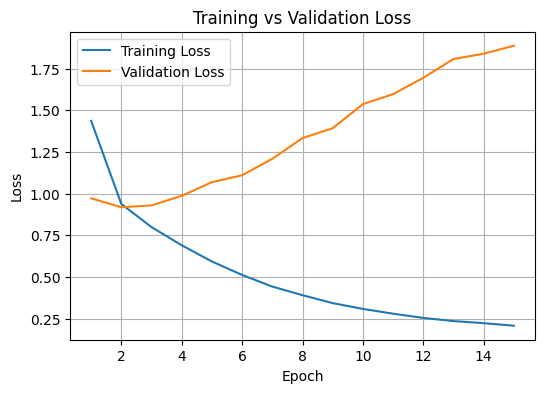

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(epochs, train_loss_plot, label="Training Loss")
plt.plot(epochs, val_loss_plot, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

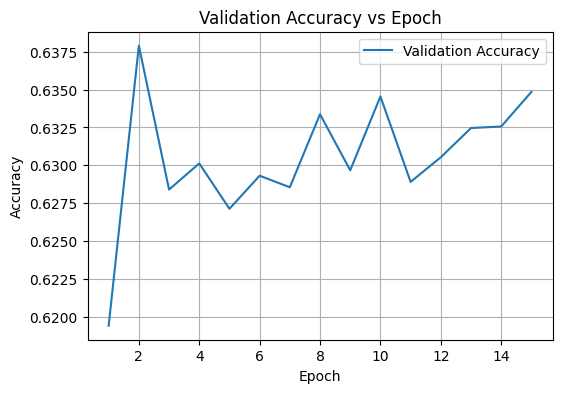

In [47]:
plt.figure(figsize=(6,4))
plt.plot(epochs, val_acc_plot, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
trainer.evaluate()

{'eval_loss': 0.8465707302093506,
 'eval_accuracy': 0.6996039905566979,
 'eval_f1': 0.6819309992268322,
 'eval_runtime': 89.6291,
 'eval_samples_per_second': 293.007,
 'eval_steps_per_second': 18.32,
 'epoch': 3.0}